In [1]:
%load_ext autoreload
%autoreload 2

# Define autroreload so that it doesn't cause pain in the ass when we change the functions and run this notebook

In [2]:
import sys
from pathlib import Path
project_root = Path.cwd().resolve().parents[2]
sys.path.append(str(project_root))

print(project_root)

C:\SenkDosya\Projects\FINCH-Science_SyntheticData


In [3]:
from defs.diffusion.diffusion import *
from defs.diffusion.loss import *
import torch.optim as optim
from defs.diffusion.noise_scheduling import *
from defs.diffusion.noise_sampling import *
from defs.diffusion.epsilon.auxiliary.model_metric import get_n_params

from defs.diffusion.epsilon.unet import *


# Predefine all the necessary inputs of the training function

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

# Loss:
loss = nn.MSELoss()

# Epsilon:
epsilon = Epsilon_Cond1DUnet(n_bands=81, in_channel=1, n_endmembers=3, channels=[128,256,512], n_former_blocks=3).to(device)



print('N of params in epsillon: ', get_n_params(epsilon))

# Scheduler:
scheduler = CosSchedule(2000)

# T sampler:
t_sampler = NormalSampling(scheduler=scheduler, t_min=0, containment_percentage=0.995)

# DDPM:
cfg_diffusion = {
    't_sampler': t_sampler
}
ddpm = cond_diffusion(epsilon=epsilon, scheduler=scheduler, ddpm_dict=cfg_diffusion)

# Optimizer:
optimizer = optim.Adam(epsilon.parameters(), lr=1e-4)


c:\Users\Ege Artan\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cuda
N of params in epsillon:  62712065


In [4]:
from defs.diffusion.training_defs import *

# Data handle:
data_handle = str(project_root)+'\data\simpler_data_rwc.csv'

# cfg_train:
cfg_train = {
    'cfg_loader': {
        'test': 23, 't_batch': 2, 'validate': 4, 'epoch': 50
    },
    'range': [900, 1700],
    'device': device,
    'tot_samples': 1723
}

# Figure out the data

# First, we will pre-process and parse all the data
# Get the spectral range that we want to use
spec_range = cfg_train.get('range', [400, 2490])

# Parse the csv into sub-parts we want to use
spectra, abundances, names, indices = get_vals(data_handle=data_handle, spec_range=spec_range, normalize=True)

# Generate the hyperspectral dataset
ds = HyperSpectralDataset(spectra=spectra, abundances=abundances, names=names, indices=indices)

# Dataload the giant dataset into train, test, validation datasets
cfg_loader = cfg_train.get(
    'cfg_loader', {'test': 23, 't_batch': 1, 'validate': 4, 'epoch': 50}
) # Get the configs for the loader first

# Get the dataloaded datasets
dataloaders= get_dataloaders(ds, cfg_loader=cfg_loader)

<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Ege Artan\AppData\Local\Temp\ipykernel_22640\2933313301.py:4: SyntaxWarning: invalid escape sequence '\d'
  data_handle = str(project_root)+'\data\simpler_data_rwc.csv'


In [5]:
collector_dict, ddpm = train_diffusion(
    cfg_train= cfg_train, cond_diffusion= ddpm, loss= loss, optimizer= optimizer, dataloaders= dataloaders 
)

Epoch 1 | Batch 1 | Total loss: 1.4930
Epoch 1 | Batch 2 | Total loss: 0.9534
Epoch 1 | Batch 3 | Total loss: 0.4097
Epoch 1 | Batch 4 | Total loss: 0.1671
Epoch 1 | Batch 5 | Total loss: 0.2664
Epoch 1 | Batch 6 | Total loss: 0.1384
Epoch 1 | Batch 7 | Total loss: 0.1786
Epoch 1 | Batch 8 | Total loss: 0.1264
Epoch 1 | Batch 9 | Total loss: 0.1007
Epoch 1 | Batch 10 | Total loss: 0.2431
Epoch 1 | Batch 11 | Total loss: 0.1918
Epoch 1 | Batch 12 | Total loss: 0.1055
Epoch 1 | Batch 13 | Total loss: 0.1110
Epoch 1 | Batch 14 | Total loss: 0.3097
Epoch 1 | Batch 15 | Total loss: 0.1264
Epoch 1 | Batch 16 | Total loss: 0.0859
Epoch 1 | Batch 17 | Total loss: 0.1831
Epoch 1 | Batch 18 | Total loss: 0.5335
Epoch 1 | Batch 19 | Total loss: 0.1125
Epoch 1 | Batch 20 | Total loss: 0.1019
Epoch 1 | Batch 21 | Total loss: 0.0717
Epoch 1 | Batch 22 | Total loss: 0.0890
Epoch 1 | Batch 23 | Total loss: 0.0841
Epoch 1 | Batch 24 | Total loss: 0.0893
Epoch 1 | Batch 25 | Total loss: 0.1428
Epoch 1 |

AttributeError: 'MSELoss' object has no attribute 'recons_loss'

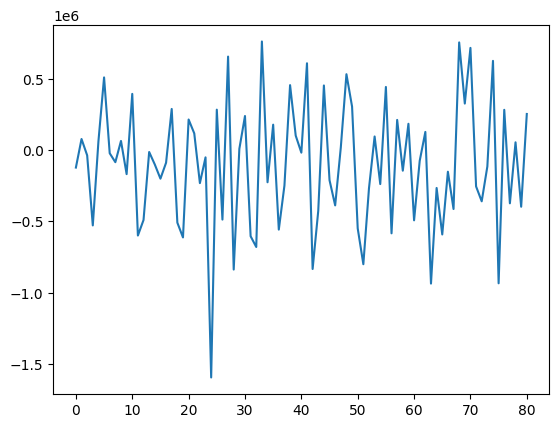

In [ ]:
import matplotlib.pyplot as plt

spectrum = collector_dict['gen_spec']['validate'][50]['generated'][3]

wavelengths = np.arange(spectrum.shape[0])

plt.plot(wavelengths, spectrum)
plt.show()
